In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('spam_ham_dataset.csv')

In [4]:
df

,label,text,label_num
0,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,spam,"Subject: photoshop , windows , office . cheap ...",1
4,ham,Subject: re : indian springs\r\nthis deal is t...,0
...,...,...,...
5166,ham,Subject: put the 10 on the ft\r\nthe transport...,0
5167,ham,Subject: 3 / 4 / 2000 and following noms\r\nhp...,0
5168,ham,Subject: calpine daily gas nomination\r\n>\r\n...,0
5169,ham,Subject: industrial worksheets for august 2000...,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   label      5171 non-null   object
 1   text       5171 non-null   object
 2   label_num  5171 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 121.3+ KB


In [6]:
df.isnull()

,label,text,label_num
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
5166,False,False,False
5167,False,False,False
5168,False,False,False
5169,False,False,False


In [7]:
df.head(3)

,label,text,label_num
0,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0


In [8]:
df.columns

Index(['label', 'text', 'label_num'], dtype='object')

In [9]:
df.describe()

,label_num
count,5171.000000
mean,0.289886
std,0.453753
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [10]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


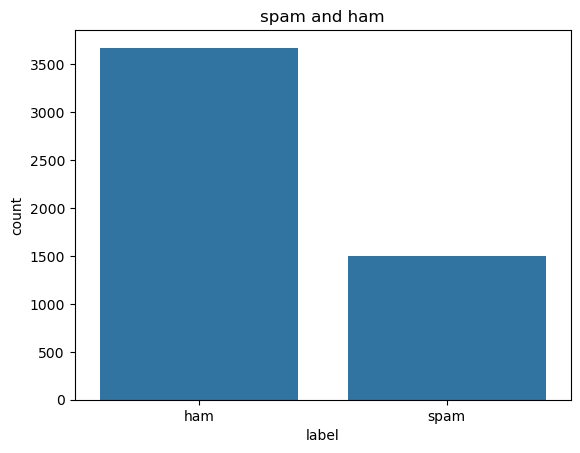

In [11]:
sns.countplot(data=df,x='label')
plt.title('spam and ham')
plt.show()

In [12]:
df.drop('label',axis=1,inplace=True)

In [13]:
pip install nltk

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [14]:
from nltk.stem import PorterStemmer,SnowballStemmer,WordNetLemmatizer
import re
import string

In [15]:
df['text'].str.lower()

0       subject: enron methanol ; meter # : 988291\r\n...
1       subject: hpl nom for january 9 , 2001\r\n( see...
2       subject: neon retreat\r\nho ho ho , we ' re ar...
3       subject: photoshop , windows , office . cheap ...
4       subject: re : indian springs\r\nthis deal is t...
                              ...                        
5166    subject: put the 10 on the ft\r\nthe transport...
5167    subject: 3 / 4 / 2000 and following noms\r\nhp...
5168    subject: calpine daily gas nomination\r\n>\r\n...
5169    subject: industrial worksheets for august 2000...
5170    subject: important online banking alert\r\ndea...
Name: text, Length: 5171, dtype: object

In [16]:
re.sub(r'\d+','',df['text'].iloc[0])

"Subject: enron methanol ; meter # : \r\nthis is a follow up to the note i gave you on monday ,  /  /  { preliminary\r\nflow data provided by daren } .\r\nplease override pop ' s daily volume { presently zero } to reflect daily\r\nactivity you can obtain from gas control .\r\nthis change is needed asap for economics purposes ."

In [17]:
df['text'].iloc[0].translate(str.maketrans('','',string.punctuation))

'Subject enron methanol  meter   988291\r\nthis is a follow up to the note i gave you on monday  4  3  00  preliminary\r\nflow data provided by daren  \r\nplease override pop  s daily volume  presently zero  to reflect daily\r\nactivity you can obtain from gas control \r\nthis change is needed asap for economics purposes '

In [18]:
df['text'].str.strip()

0       Subject: enron methanol ; meter # : 988291\r\n...
1       Subject: hpl nom for january 9 , 2001\r\n( see...
2       Subject: neon retreat\r\nho ho ho , we ' re ar...
3       Subject: photoshop , windows , office . cheap ...
4       Subject: re : indian springs\r\nthis deal is t...
                              ...                        
5166    Subject: put the 10 on the ft\r\nthe transport...
5167    Subject: 3 / 4 / 2000 and following noms\r\nhp...
5168    Subject: calpine daily gas nomination\r\n>\r\n...
5169    Subject: industrial worksheets for august 2000...
5170    Subject: important online banking alert\r\ndea...
Name: text, Length: 5171, dtype: object

In [19]:
from wordcloud import WordCloud

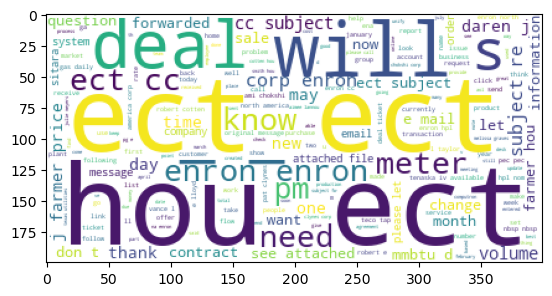

In [20]:
wc=WordCloud(background_color='white').generate(df['text'].str.cat())
plt.imshow(wc)
plt.show()

In [21]:
for i in df['text']:
    for j in i.split():
        if j.lower()=='ect':
            print(i)

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



Subject: meter 984132 for 1 / 16 / 99
hi daren ,
can you give us a status on this request ?
thanks
- jackie -
3 - 9497
- - - - - - - - - - - - - - - - - - - - - - forwarded by jackie young / hou / ect on 08 / 30 / 2000 12 : 22
pm - - - - - - - - - - - - - - - - - - - - - - - - - - -
daren j farmer
08 / 23 / 2000 12 : 59 pm
to : jackie young / hou / ect @ ect
cc :
subject : meter 984132 for 1 / 16 / 99
jackie ,
what does mops show for the days in question ? it would be incorrect to add
any days to the adonis ticket mentioned below . it sounds as if the meter was
allocated incorrectly in pops and / or a deal was not pathed correctly in
mops . let me know what you find in mops .
d
- - - - - - - - - - - - - - - - - - - - - - forwarded by daren j farmer / hou / ect on 08 / 23 / 2000
12 : 54 pm - - - - - - - - - - - - - - - - - - - - - - - - - - -
enron north america corp .
from : gary w lamphier 08 / 22 / 2000 02 : 51 pm
to : daren j farmer / hou / ect @ ect
cc :
subject : meter 984132 for 

In [22]:
def clean_text(text):
    text=text.lower()
    text=re.sub(r'\d+','',text)
    text=text.translate(str.maketrans('','',string.punctuation))
    text=text.strip()
    text=text.replace('Subject','').replace('ect','').replace('cc','')

    st=PorterStemmer()
    text=st.stem(text)
    return text

In [23]:
df['clean_text']=df['text'].apply(clean_text)

In [24]:
df

,text,label_num,clean_text
0,Subject: enron methanol ; meter # : 988291\r\n...,0,subj enron methanol meter \r\nthis is a fol...
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",0,subj hpl nom for january \r\n see attached f...
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0,subj neon retreat\r\nho ho ho we re around t...
3,"Subject: photoshop , windows , office . cheap ...",1,subj photoshop windows office cheap main t...
4,Subject: re : indian springs\r\nthis deal is t...,0,subj re indian springs\r\nthis deal is to boo...
...,...,...,...
5166,Subject: put the 10 on the ft\r\nthe transport...,0,subj put the on the ft\r\nthe transport volum...
5167,Subject: 3 / 4 / 2000 and following noms\r\nhp...,0,subj and following noms\r\nhpl can t tak...
5168,Subject: calpine daily gas nomination\r\n>\r\n...,0,subj calpine daily gas nomination\r\n\r\n\r\nj...
5169,Subject: industrial worksheets for august 2000...,0,subj industrial worksheets for august activit...


In [25]:
import re
import string
from nltk.stem import PorterStemmer
st=PorterStemmer()

def clean_text(text):
    text=text.lower()
    text=re.sub(r'\d+','',text)
    text=text.translate(str.maketrans('','',string.punctuation))
    text=text.strip()
    text=text.replace('subject','').strip()
    text=' '.join([st.stem(word) for word in text.split()])
    return text

In [26]:
df['clean_text']=df['text'].apply(clean_text)

In [31]:
df.drop('label', axis=1, inplace=True, errors='ignore')


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [32]:
vectorizer=TfidfVectorizer(stop_words='english')

In [33]:
tfidf=vectorizer.fit_transform(['i like apples','i like oranges', 'i like apples and oranges'])

pd.DataFrame(tfidf.toarray(),columns=vectorizer.get_feature_names_out())

,apples,like,oranges
0,0.789807,0.613356,0.000000
1,0.000000,0.613356,0.789807
2,0.619805,0.481334,0.619805


In [34]:
X=vectorizer.fit_transform(df['clean_text'])
y=df['label_num']

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.2)

In [37]:
from sklearn.naive_bayes import MultinomialNB

In [38]:
nb=MultinomialNB()

In [39]:
nb.fit(X_train,y_train)

MultinomialNB()

In [40]:
y_pred=nb.predict(X_test)

In [41]:
from sklearn.metrics import classification_report

In [42]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95       741
           1       0.99      0.76      0.86       294

    accuracy                           0.93      1035
   macro avg       0.95      0.88      0.90      1035
weighted avg       0.93      0.93      0.93      1035



In [43]:
def predict_email(text):
    cleaned=clean_text(text)
    vectorized=vectorizer.transform([cleaned])
    pred=nb.predict(vectorized)[0]
    if pred==1:
        print('This seems like a Spam Email')
    else:
        print('This seems like a Genuine Email')

In [44]:
example_text='Hello! We are interested in scheduling a call for the conversation we had earlier '
predict_email(example_text)

This seems like a Genuine Email
